# **XII) SHAP Analysis**

implements an Explainable AI (XAI) framework using SHAP (SHapley Additive exPlanations) to interpret the LSTM model's predictions.




1. [**Imports and Global Configuration**](#1-import--config)
2. [**Core SHAP Extraction**](#2-shap--extraction)
3. [**Fold-Specific Importance Analysis**](#3-fold--feature)
4. [**Cross-Fold Aggregation & LaTeX Reporting**](#4-fold--latex)
5. [**Temporal Dynamics**](#5-temporal)
6. [**Global Aggregated SHAP Plot**](#6-global--agg--shap)
7. [**Global Disaggregated SHAP Plot**](#7-global--disagg--shap)
8. [**Importance by Feature and Lag**](#8-importance--lag)
9. [**Top 10 Features: Importance and Lag (Aggregated)**](#9-top10--features--agg)
10. [**Regime-Dependent Interaction Analysis MPE and FFR**](#10-interactions)
11. [**Regime-Dependent Interaction Analysis MPE and FFR (Aggregated)**](#11-interactions--agg)




### **1) Imports and Global Configuration** <a id="1-import--config"></a>

In [1]:
# pip install seaborn shap
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import tensorflow as tf
from scipy import stats
from scipy.stats.mstats import winsorize

names = {
    "btc_ret_lag1": "BTC", 
    "btc_ret": "Btc", "mp_exp": "MPE", 
    "news_sent": "NewsSent", "policy_risk_gr": "PolUncert",
    "sp500_ret": "SP500", "brent_gr": "Brent", 
    "gold_ret": "Gold", "hy_ret": "HighYield",
    "gpr_gr": "GeopolRisk", "vix_gr": "VIX", "dxy_gr": "USDollar",
    "emv": "Infect",
    "claims_dlog": "JoblessClaim", "eer_dlog": "ExchRate", 
    "ffr": "FFR", "infl5y": "5yInflExp",
    "gt_infl": "GgleInfl", "gt_recess": "GgleReces",
    "gt_climate": "GgleClimate",
}

SAVE_DIR = "data/saved_folds"
FOLDS = ["fold1", "fold2", "fold3", "fold4"]
TOP_N = 20


### **2) Core SHAP Extraction** <a id="2-shap--extraction"></a>


In [2]:


def get_lag_label(lag_idx, total_lags):
    """Maps index 0..N to t, t-1, etc. based on temporal order."""
    # Assuming the last index is 't' (most recent)
    offset = (total_lags - 1) - lag_idx
    if offset == 0:
        return "t"
    return f"t-{offset}"

def compute_and_save_shap(fold_dir):
    """Compute SHAP only once and save to disk."""
    model = tf.keras.models.load_model(os.path.join(fold_dir, "model.keras"))
    X_bg = np.load(os.path.join(fold_dir, "X_background.npy"))
    X_ex = np.load(os.path.join(fold_dir, "X_explain.npy"))

    explainer = shap.GradientExplainer(model, X_bg)
    shap_vals = explainer.shap_values(X_ex)

    # GradientExplainer returns a list [values]. We need the array inside.
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[0]
    
    # Save the numpy array
    shp_path = os.path.join(fold_dir, "shap_values.npy")
    np.save(shp_path, shap_vals)
    
    return shap_vals

def load_meta(fold_dir):
    meta = pd.read_json(os.path.join(fold_dir, "meta.json"), typ="series")
    return list(meta["features"]) 

def load_shap_detailed(fold_dir, features):
    """Loads SHAP and keeps the lag dimension."""
    shp_path = os.path.join(fold_dir, "shap_values.npy")
    if not os.path.exists(shp_path):
        shap_vals = compute_and_save_shap(fold_dir)
    else:
        shap_vals = np.load(shp_path)

    # Squeeze any trailing singleton dimensions (e.g., shape (N, L, F, 1) -> (N, L, F))
    shap_vals = np.squeeze(shap_vals)
    
    # Ensure it's 3D: (samples, lags, features)
    if shap_vals.ndim != 3:
        raise ValueError(f"Expected 3D SHAP values (samples, lags, features), got {shap_vals.shape}")

    num_lags = shap_vals.shape[1]
    
    # Global (Aggregated) Importance: Mean over samples and lags
    # axis=(0, 1) means we average over samples and the lag dimension
    global_imp = np.abs(shap_vals).mean(axis=(0, 1))
    
    # This now correctly creates a 1D Series
    global_series = pd.Series(global_imp, index=features)

    # Disaggregated Importance: Mean over samples ONLY
    diag_imp = np.abs(shap_vals).mean(axis=0)
    
    rows = []
    for l_idx in range(num_lags):
        lag_suffix = get_lag_label(l_idx, num_lags)
        for f_idx, feat_name in enumerate(features):
            rows.append({
                "feature_full": f"{names.get(feat_name, feat_name)} ({lag_suffix})",
                "importance": diag_imp[l_idx, f_idx]
            })
    
    diag_series = pd.DataFrame(rows).set_index("feature_full")["importance"]
    
    return global_series, diag_series

def plot_importance(series, top_n ):
    top = series.sort_values(ascending=True).tail(top_n)

    plt.figure(figsize=(4.5, 3.2))
    plt.barh(top.index, top.values, color="lightslategray", edgecolor="black", linewidth=0.5)
    plt.xlabel("Mean(|SHAP|)")
    plt.grid(axis='x', linestyle='--', alpha=0.6)

def plot_importance_with_err(mean_series, std_series, top_n, title=""):
    top_idx = mean_series.sort_values(ascending=True).tail(top_n).index
    plt.figure(figsize=(4.5, 3.2))
    plt.barh(top_idx, mean_series[top_idx], xerr=std_series[top_idx], 
             capsize=3, color="lightslategray", edgecolor="black", linewidth=0.5)
    plt.xlabel("Mean(|SHAP|)")
    plt.title(title, fontsize=10)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

### **3) Fold-Specific Importance Analysis** <a id="3-fold--feature"></a>



==================== FOLD1 (Mean ± Std of 5 Runs) ====================


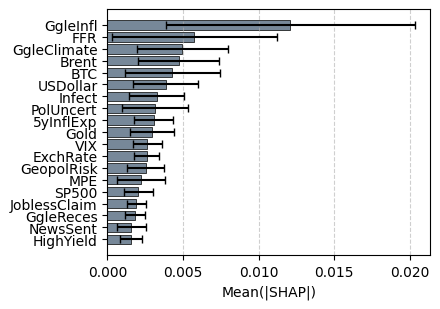

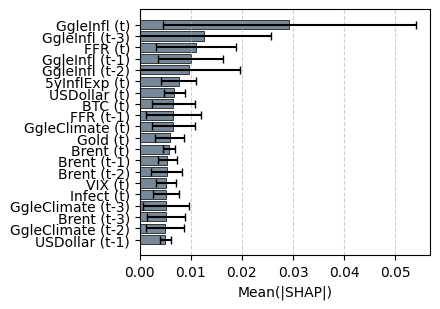


==================== FOLD2 (Mean ± Std of 5 Runs) ====================


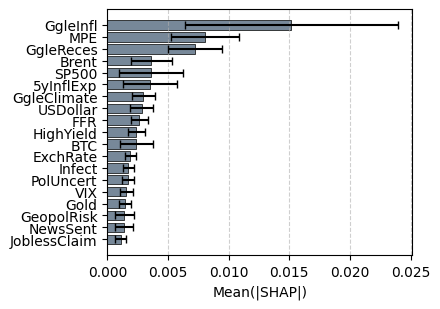

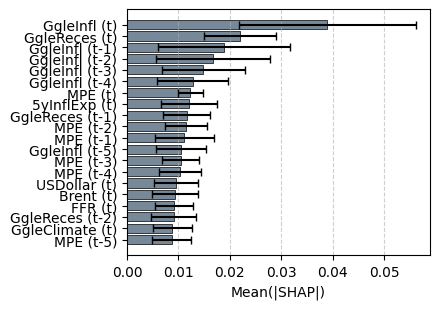


==================== FOLD3 (Mean ± Std of 5 Runs) ====================


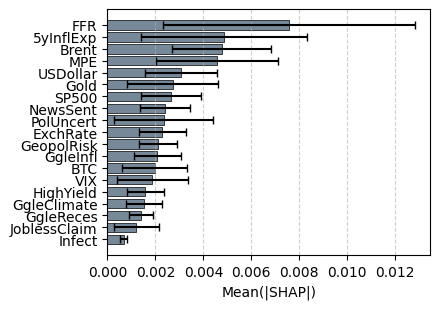

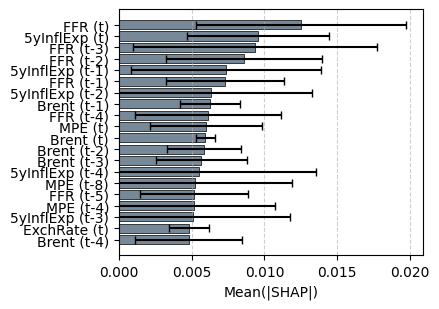


==================== FOLD4 (Mean ± Std of 5 Runs) ====================


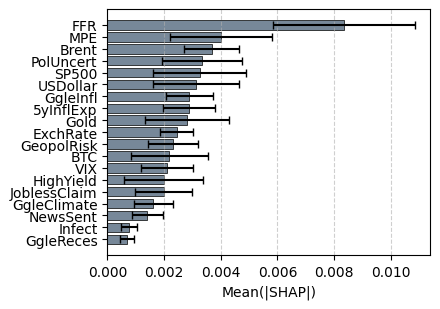

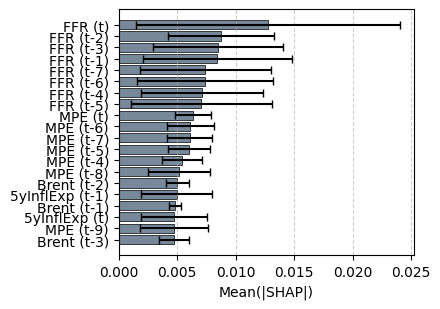

In [3]:

all_fold_rows = []

for fold in FOLDS:
    run_dirs = [os.path.join(SAVE_DIR, d) for d in os.listdir(SAVE_DIR) 
                if d.startswith(fold) and os.path.isdir(os.path.join(SAVE_DIR, d))]
    
    if not run_dirs: continue

    fold_global_list = []
    fold_diag_list = []

    for fold_dir in run_dirs:
        features = load_meta(fold_dir)
        global_imp, diag_imp = load_shap_detailed(fold_dir, features)
        
        fold_global_list.append(global_imp)
        fold_diag_list.append(diag_imp)
        
        # Collect for global final analysis
        df_run = global_imp.reset_index()
        df_run.columns = ["feature", "mean_abs_shap"]
        df_run["fold"] = fold
        all_fold_rows.append(df_run)

    # Compute per-fold Mean and Std across the 5 runs
    df_global_fold = pd.concat(fold_global_list, axis=1)
    avg_global_imp = df_global_fold.mean(axis=1)
    std_global_imp = df_global_fold.std(axis=1)

    df_diag_fold = pd.concat(fold_diag_list, axis=1)
    avg_diag_imp = df_diag_fold.mean(axis=1)
    std_diag_imp = df_diag_fold.std(axis=1)

    # Map names for plotting
    avg_global_mapped = avg_global_imp.rename(index=lambda x: names.get(x, x))
    std_global_mapped = std_global_imp.rename(index=lambda x: names.get(x, x))

    print(f"\n{'='*20} {fold.upper()} (Mean ± Std of 5 Runs) {'='*20}")
    
    # Plot per-fold aggregated with error bars
    plot_importance_with_err(avg_global_mapped, std_global_mapped, TOP_N)
    plt.tight_layout()
    plt.savefig(f"figures/shap_fold_{fold[-1]}.pdf")
    plt.show()

    # Plot per-fold disaggregated with error bars
    plot_importance_with_err(avg_diag_imp, std_diag_imp, TOP_N)
    plt.tight_layout()
    plt.xlim([0, None])
    plt.savefig(f"figures/shap_lag_fold_{fold[-1]}.pdf")
    plt.show()

### **4) Cross-Fold Aggregation & LaTeX Reporting** <a id="4-fold--latex"></a>


In [4]:
# Global Aggregated Table 
# Combine the results collected in the main loop
global_abs_df = pd.concat(all_fold_rows, ignore_index=True)

# Map raw codes to academic names
global_abs_df["academic_name"] = global_abs_df["feature"].map(names).fillna(global_abs_df["feature"])

# Pivot for Mean and Std simultaneously
pivot_stats = global_abs_df.pivot_table(
    index="academic_name",
    columns="fold",
    values="mean_abs_shap",
    aggfunc=["mean", "std"]
).fillna(0.0)

# Calculate Overall Mean and Std across all folds/runs
overall_mean = global_abs_df.groupby("academic_name")["mean_abs_shap"].mean()
overall_std = global_abs_df.groupby("academic_name")["mean_abs_shap"].std().fillna(0.0)

# Create the formatted DataFrame
df_formatted = pd.DataFrame(index=pivot_stats.index)

# Calculate Rank based on the overall mean
df_formatted["rank"] = overall_mean.rank(ascending=False, method="dense").astype(int)

# Add Formatted Overall Average: Mean (SD)
df_formatted["avg_importance"] = [f"{m:.3f} ({s:.3f})" for m, s in zip(overall_mean, overall_std)]

# Add Formatted Per-Fold Columns: Mean (SD)
fold_names = sorted(global_abs_df["fold"].unique())
for fld in fold_names:
    means = pivot_stats["mean"][fld]
    stds = pivot_stats["std"][fld]
    df_formatted[fld] = [f"{m:.3f} ({s:.3f})" for m, s in zip(means, stds)]

# Sort by Rank
df_ranked_global = df_formatted.sort_values("rank")

print("Table: Global Feature Importance (Aggregated across Lags) - Mean (SD)")
display(df_ranked_global.head(20))


Table: Global Feature Importance (Aggregated across Lags) - Mean (SD)


,rank,avg_importance,fold1,fold2,fold3,fold4
academic_name,,,,,,
GgleInfl,1,0.008 (0.008),0.012 (0.008),0.015 (0.009),0.002 (0.001),0.003 (0.001)
FFR,2,0.006 (0.004),0.006 (0.005),0.003 (0.001),0.008 (0.005),0.008 (0.002)
MPE,3,0.005 (0.003),0.002 (0.002),0.008 (0.003),0.005 (0.003),0.004 (0.002)
Brent,4,0.004 (0.002),0.005 (0.003),0.004 (0.002),0.005 (0.002),0.004 (0.001)
5yInflExp,5,0.004 (0.002),0.003 (0.001),0.003 (0.002),0.005 (0.003),0.003 (0.001)
USDollar,6,0.003 (0.002),0.004 (0.002),0.003 (0.001),0.003 (0.001),0.003 (0.002)
SP500,7,0.003 (0.002),0.002 (0.001),0.004 (0.003),0.003 (0.001),0.003 (0.002)
GgleReces,8,0.003 (0.003),0.002 (0.001),0.007 (0.002),0.001 (0.001),0.001 (0.000)
GgleClimate,9,0.003 (0.002),0.005 (0.003),0.003 (0.001),0.002 (0.001),0.002 (0.001)


In [5]:
df_global_latex = df_ranked_global.head(20).copy()

# Italicize the index and escape underscores
df_global_latex.index = df_global_latex.index.map(
    lambda x: f"\\textit{{{str(x).replace('_', '\\_')}}}"
)

latex_str = df_global_latex.to_latex(
    caption="Global Feature Importance: Mean Absolute SHAP Values (SD in Parentheses)",
    label="tab:global_shap_sd",
    column_format="l c l " + "l"*len(fold_names),
    escape=False  # Required to interpret \textit and \_ correctly
)

print(latex_str)

\begin{table}
\caption{Global Feature Importance: Mean Absolute SHAP Values (SD in Parentheses)}
\label{tab:global_shap_sd}
\begin{tabular}{l c l llll}
\toprule
 & rank & avg_importance & fold1 & fold2 & fold3 & fold4 \\
academic_name &  &  &  &  &  &  \\
\midrule
\textit{GgleInfl} & 1 & 0.008 (0.008) & 0.012 (0.008) & 0.015 (0.009) & 0.002 (0.001) & 0.003 (0.001) \\
\textit{FFR} & 2 & 0.006 (0.004) & 0.006 (0.005) & 0.003 (0.001) & 0.008 (0.005) & 0.008 (0.002) \\
\textit{MPE} & 3 & 0.005 (0.003) & 0.002 (0.002) & 0.008 (0.003) & 0.005 (0.003) & 0.004 (0.002) \\
\textit{Brent} & 4 & 0.004 (0.002) & 0.005 (0.003) & 0.004 (0.002) & 0.005 (0.002) & 0.004 (0.001) \\
\textit{5yInflExp} & 5 & 0.004 (0.002) & 0.003 (0.001) & 0.003 (0.002) & 0.005 (0.003) & 0.003 (0.001) \\
\textit{USDollar} & 6 & 0.003 (0.002) & 0.004 (0.002) & 0.003 (0.001) & 0.003 (0.001) & 0.003 (0.002) \\
\textit{SP500} & 7 & 0.003 (0.002) & 0.002 (0.001) & 0.004 (0.003) & 0.003 (0.001) & 0.003 (0.002) \\
\textit{GgleRec

### **5) Temporal Dynamics** <a id="5-temporal"></a>


In [6]:
diag_run_rows = []

for run_folder in os.listdir(SAVE_DIR):
    run_path = os.path.join(SAVE_DIR, run_folder)
    
    if os.path.isdir(run_path) and any(run_folder.startswith(f) for f in FOLDS):
        features = load_meta(run_path)
        _, diag_imp = load_shap_detailed(run_path, features) 
        
        # Extract base fold name (e.g., "fold1")
        base_fold = run_folder.split('_')[0]
        
        df_diag = diag_imp.reset_index()
        df_diag.columns = ["feature_lag", "importance"]
        df_diag["base_fold"] = base_fold
        df_diag["run_folder"] = run_folder 
        diag_run_rows.append(df_diag)

diag_all_runs_df = pd.concat(diag_run_rows, ignore_index=True)

pivot_diag_stats = diag_all_runs_df.pivot_table(
    index="feature_lag",
    columns="base_fold",
    values="importance",
    aggfunc=["mean", "std"]
).fillna(0.0)

overall_diag_mean = diag_all_runs_df.groupby("feature_lag")["importance"].mean()
overall_diag_std = diag_all_runs_df.groupby("feature_lag")["importance"].std().fillna(0.0)

df_diag_formatted = pd.DataFrame(index=pivot_diag_stats.index)

# Calculate Rank based on overall importance
df_diag_formatted["rank"] = overall_diag_mean.rank(ascending=False, method="dense").astype(int)

# Add Formatted Overall Average: Mean (SD)
df_diag_formatted["avg_importance"] = [
    f"{m:.3f} ({s:.3f})" for m, s in zip(overall_diag_mean, overall_diag_std)
]

# Add Formatted Per-Fold Columns: Mean (SD)
base_folds = sorted(diag_all_runs_df["base_fold"].unique())
for fld in base_folds:
    means = pivot_diag_stats["mean"][fld]
    stds = pivot_diag_stats["std"][fld]
    df_diag_formatted[fld] = [f"{m:.3f} ({s:.3f})" for m, s in zip(means, stds)]

df_ranked_diag_final = df_diag_formatted.sort_values("rank")

print("Table: Disaggregated Feature-Lag Importance - Mean (SD across 5 runs)")
display(df_ranked_diag_final.head(20))

Table: Disaggregated Feature-Lag Importance - Mean (SD across 5 runs)


,rank,avg_importance,fold1,fold2,fold3,fold4
feature_lag,,,,,,
GgleInfl (t),1,0.019 (0.021),0.029 (0.025),0.039 (0.017),0.003 (0.001),0.003 (0.002)
FFR (t),2,0.011 (0.007),0.011 (0.008),0.009 (0.004),0.013 (0.007),0.013 (0.011)
5yInflExp (t),3,0.009 (0.005),0.008 (0.003),0.012 (0.005),0.010 (0.005),0.005 (0.003)
GgleInfl (t-1),4,0.008 (0.010),0.010 (0.006),0.019 (0.013),0.002 (0.001),0.002 (0.001)
GgleInfl (t-3),5,0.008 (0.009),0.013 (0.013),0.015 (0.008),0.002 (0.002),0.003 (0.001)
GgleInfl (t-2),6,0.008 (0.009),0.010 (0.010),0.017 (0.011),0.002 (0.001),0.002 (0.001)
MPE (t),7,0.007 (0.004),0.004 (0.002),0.012 (0.002),0.006 (0.004),0.006 (0.002)
GgleReces (t),8,0.007 (0.010),0.004 (0.003),0.022 (0.007),0.002 (0.001),0.001 (0.000)
FFR (t-1),9,0.007 (0.005),0.007 (0.005),0.005 (0.003),0.007 (0.004),0.008 (0.006)


In [7]:
# Apply italics to the index values directly
df_ranked_diag_final.index = df_ranked_diag_final.index.map(lambda x: f"\\textit{{{x}}}")

latex_diag = df_ranked_diag_final.head(20).to_latex(
    column_format="l c l " + "c"*len(base_folds),
    caption="Disaggregated Feature-Lag Importance: Mean Absolute SHAP (SD)",
    label="tab:diag_shap_sd",
    header=["Rank", "Average (SD)", "Fold 1", "Fold 2", "Fold 3", "Fold 4"],
    escape=False  # This is crucial so LaTeX doesn't escape the backslashes
)

print(latex_diag)

\begin{table}
\caption{Disaggregated Feature-Lag Importance: Mean Absolute SHAP (SD)}
\label{tab:diag_shap_sd}
\begin{tabular}{l c l cccc}
\toprule
 & Rank & Average (SD) & Fold 1 & Fold 2 & Fold 3 & Fold 4 \\
feature_lag &  &  &  &  &  &  \\
\midrule
\textit{GgleInfl (t)} & 1 & 0.019 (0.021) & 0.029 (0.025) & 0.039 (0.017) & 0.003 (0.001) & 0.003 (0.002) \\
\textit{FFR (t)} & 2 & 0.011 (0.007) & 0.011 (0.008) & 0.009 (0.004) & 0.013 (0.007) & 0.013 (0.011) \\
\textit{5yInflExp (t)} & 3 & 0.009 (0.005) & 0.008 (0.003) & 0.012 (0.005) & 0.010 (0.005) & 0.005 (0.003) \\
\textit{GgleInfl (t-1)} & 4 & 0.008 (0.010) & 0.010 (0.006) & 0.019 (0.013) & 0.002 (0.001) & 0.002 (0.001) \\
\textit{GgleInfl (t-3)} & 5 & 0.008 (0.009) & 0.013 (0.013) & 0.015 (0.008) & 0.002 (0.002) & 0.003 (0.001) \\
\textit{GgleInfl (t-2)} & 6 & 0.008 (0.009) & 0.010 (0.010) & 0.017 (0.011) & 0.002 (0.001) & 0.002 (0.001) \\
\textit{MPE (t)} & 7 & 0.007 (0.004) & 0.004 (0.002) & 0.012 (0.002) & 0.006 (0.004) & 0.006

### **6) Global Aggregated SHAP Plot** <a id="6-global--agg--shap"></a>


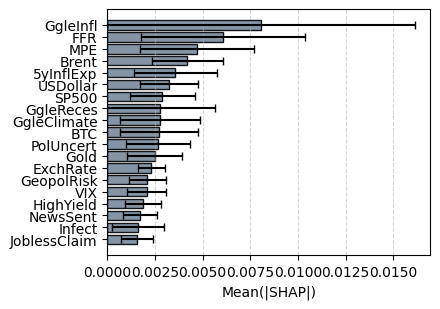

In [8]:
df_all_global = pd.concat(all_fold_rows, ignore_index=True)

stats_global = (
    df_all_global.groupby("feature")["mean_abs_shap"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=True) # Ascending for horizontal bar plot
)

stats_global.index = stats_global.index.map(lambda x: names.get(x, x))

plt.figure(figsize=(4.5, 3.2))
plt.barh(
    stats_global.tail(TOP_N).index, 
    stats_global.tail(TOP_N)["mean"],
    xerr=stats_global.tail(TOP_N)["std"],
    capsize=3, color="lightslategray", edgecolor="black", linewidth=1, alpha=0.9
)

plt.xlabel("Mean(|SHAP|)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim([0,None])
plt.tight_layout()
plt.savefig(f"figures/shap_avg.pdf")
plt.show()
    

### **7) Global Disaggregated SHAP Plot** <a id="7-global--disagg--shap"></a>


Top 20 Disaggregated Features (Aggregated)


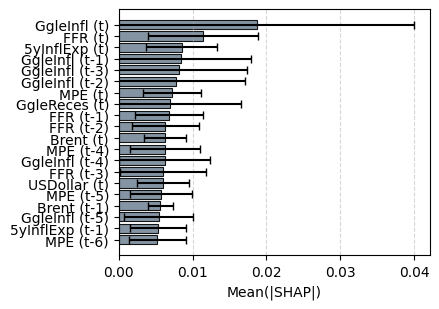

In [9]:
TOP_N_LAG = 20

if 'diag_all_runs_df' in locals():
    df_plot_diag = diag_all_runs_df.copy()
else:
    # Fallback/Safety: Combine all rows if not already done
    df_plot_diag = pd.concat(diag_run_rows, ignore_index=True)

stats_diag = (
    df_plot_diag.groupby("feature_lag")["importance"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=True)
)

plt.figure(figsize=(4.5, 3.2))
top_stats = stats_diag.tail(TOP_N_LAG)

plt.barh(
    top_stats.index, 
    top_stats["mean"],
    xerr=top_stats["std"], # Error bar now shows variation across all runs/folds
    capsize=3, 
    color="lightslategray", 
    edgecolor="black", 
    linewidth=0.8, 
    alpha=0.9
)

plt.xlabel("Mean(|SHAP|)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim([0, None])

# Add a subtle title to indicate aggregation
print(f"Top {TOP_N_LAG} Disaggregated Features (Aggregated)")
plt.tight_layout()
plt.savefig("figures/shap_lag_avg.pdf", bbox_inches='tight')
plt.show()

### **8) Importance by Feature and Lag** <a id="8-importance--lag"></a>

In [10]:
profile_data = []

top_features = df_ranked_global.head(15).index

# and contains the 'avg_importance' column.
for feat in top_features:
    # We search the index of df_ranked_diag_final for the feature name
    # e.g., finding "Btc (t)", "Btc (t-1)" by searching for "Btc"
    feat_lags = df_ranked_diag_final[df_ranked_diag_final.index.str.contains(feat, regex=False)].copy()
    
    if feat_lags.empty:
        continue
        
    # Convert 'avg_importance' back to float (it was a string "Mean (SD)")
    # We extract the mean part before the parenthesis
    feat_lags['numeric_imp'] = feat_lags['avg_importance'].apply(lambda x: float(x.split(' ')[0]))
    feat_lags = feat_lags.sort_values("numeric_imp", ascending=False)
    
    total_feat_imp = feat_lags["numeric_imp"].sum()
    feat_lags["share"] = feat_lags["numeric_imp"] / total_feat_imp
    
    significant_lags = []
    cum_share = 0
    for idx, row in feat_lags.iterrows():
        # Extract lag: "USDollar (t-1)" -> "t-1"
        lag_label = idx.split('(')[-1].replace(')', '').strip()
        significant_lags.append(lag_label)
        cum_share += row["share"]
        if cum_share > 0.8: 
            break
    
    top_share = feat_lags["share"].iloc[0]
    profile = "Sharp" if top_share > 0.6 else "Gradual"
    
    profile_data.append({
        "Feature": feat,
        "Significant Lags": ", ".join(significant_lags),
        "Temporal Profile": profile,
        "Top Lag Share": f"{top_share:.1%}"
    })

df_profile = pd.DataFrame(profile_data)
display(df_profile)

,Feature,Significant Lags,Temporal Profile,Top Lag Share
0,GgleInfl,"t}, t-1}, t-3}, t-2}, t-4}, t-5}, t-6}, t-7}",Gradual,25.3%
1,FFR,"t}, t-1}, t-2}, t-3}, t-4}, t-5}, t-6}, t-7}",Gradual,21.2%
2,MPE,"t}, t-4}, t-5}, t-6}, t-3}, t-2}, t-1}, t-7}, ...",Gradual,11.5%
3,Brent,"t}, t-1}, t-2}, t-3}, t-4}, t-5}, t-6}, t-7}",Gradual,15.8%
4,5yInflExp,"t}, t-1}, t-2}, t-3}, t-4}, t-5}, t-6}",Gradual,25.0%
5,USDollar,"t}, t-1}, t-2}, t-3}, t-4}, t-5}, t-6}, t-7}",Gradual,21.4%
6,SP500,"t}, t-1}, t-2}, t-3}, t-4}, t-5}, t-6}, t-7}, ...",Gradual,15.6%
7,GgleReces,"t}, t-1}, t-2}, t-4}, t-3}, t-5}, t-6}, t-7}",Gradual,21.9%
8,GgleClimate,"t}, t-1}, t-2}, t-3}, t-4}, t-5}, t-6}, t-7}",Gradual,19.2%
9,BTC,"t}, t-1}, t-2}, t-4}, t-3}, t-5}, t-6}, t-7}",Gradual,17.2%


### **9) Top 10 Features: Importance and Lag** <a id="9-top10--features"></a>

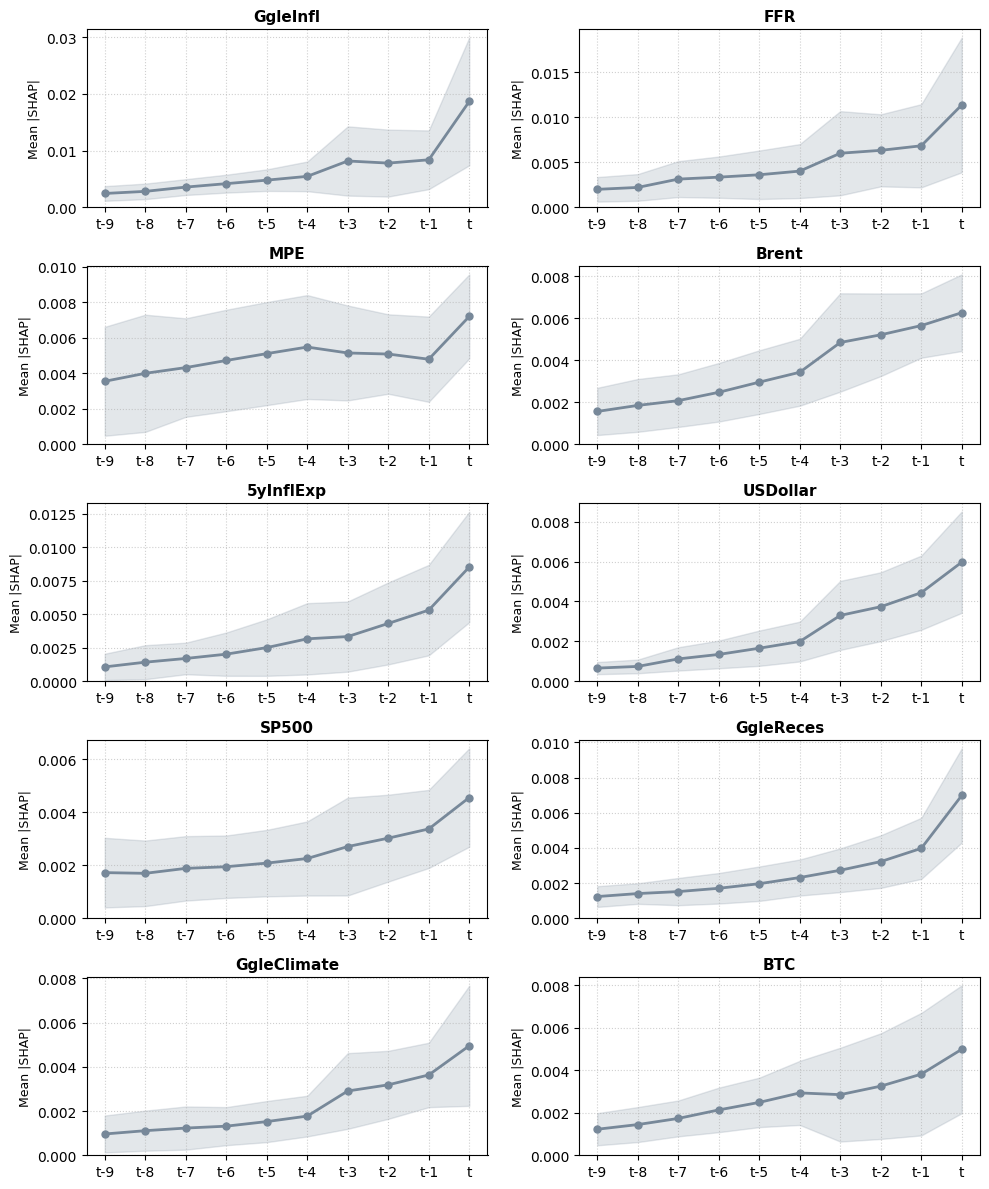

In [11]:
# Identify top 10 features from the GLOBAL ranked results
top_10_global = df_ranked_global.head(10).index.tolist()

plot_df = pivot_diag_stats.copy()

def parse_index(idx):
    base_name = idx.split(' (')[0]
    if '(t)' in idx: 
        return base_name, 0
    match = re.search(r'\(t-(\d+)\)', idx)
    return base_name, int(match.group(1)) if match else 0

parsed = [parse_index(i) for i in plot_df.index]
plot_df['base_feature'] = [p[0] for p in parsed]
plot_df['lag_idx'] = [p[1] for p in parsed]

# We look inside one of the MultiIndex levels to get these strings
fold_names = plot_df.columns.get_level_values(1).unique()
fold_names = [f for f in fold_names if 'fold' in str(f)]

# Plot
fig, axes = plt.subplots(5, 2, figsize=(10, 12)) # Slightly larger for clarity
axes = axes.flatten()

for i, feature in enumerate(top_10_global):
    ax = axes[i]
    
    # Filter for the feature and sort lags: oldest (t-n) to newest (t)
    subset = plot_df[plot_df['base_feature'] == feature].copy()
    subset = subset.sort_values('lag_idx', ascending=False)
    subset = subset.tail(10)
    # ------------------------------------------------

    if subset.empty:
        continue

    # .xs('mean', axis=1) isolates just the mean columns for all folds
    means_per_fold = subset.xs('mean', axis=1, level=0)[fold_names]
    stds_per_fold = subset.xs('std', axis=1, level=0)[fold_names]
    
    # Calculate the cross-fold average and the cross-fold uncertainty
    mean_val = means_per_fold.mean(axis=1).values
    std_val = stds_per_fold.mean(axis=1).values 
    
    x_labels = [f"t-{int(l)}" if l > 0 else "t" for l in subset['lag_idx']]
    
    ax.plot(x_labels, mean_val, marker='o', color='lightslategray', 
            linewidth=2, markersize=5, label='Mean SHAP')
    ax.fill_between(x_labels, mean_val - std_val, mean_val + std_val, 
                    alpha=0.2, color='lightslategray')
    
    ax.set_title(f"{feature}", fontweight='bold', fontsize=11)
    ax.set_ylabel("Mean |SHAP|", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_ylim(0, None) 

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/temporal_signatures.pdf", bbox_inches='tight')
plt.show()

### **9) Top 10 Features: Importance and Lag (Aggregated)** <a id="9-top10--features--agg"></a>

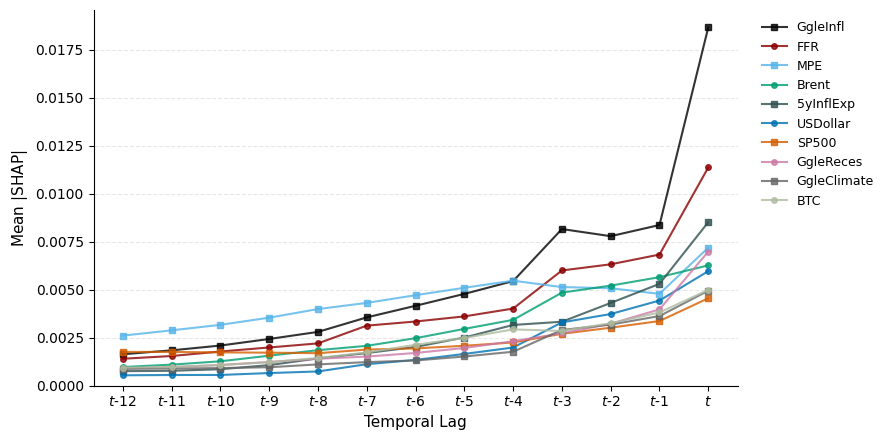

In [12]:
# Identify top 10 features from the GLOBAL ranked results
top_10_global = df_ranked_global.head(10).index.tolist()

plot_df = pivot_diag_stats.copy()

# Re-apply parsing
def parse_index(idx):
    base_name = idx.split(' (')[0]
    if '(t)' in idx: return base_name, 0
    match = re.search(r'\(t-(\d+)\)', idx)
    return base_name, int(match.group(1)) if match else 0

parsed = [parse_index(i) for i in plot_df.index]
plot_df['base_feature'] = [p[0] for p in parsed]
plot_df['lag_idx'] = [p[1] for p in parsed]

# Identify the fold columns specifically within the 'mean' level
fold_names = plot_df.columns.get_level_values(1).unique()
fold_names = [f for f in fold_names if 'fold' in str(f)]

list_colors = [
    "#000000", "#8B0000", "#56B4E9", "#009E73",  
    "#2F4F4F", "#0072B2", "#D55E00", "#CC79A7",  
    "#666666", "#ADBC9F"
]

plt.figure(figsize=(9, 4.5))

for i, feature in enumerate(top_10_global):
    subset = plot_df[plot_df['base_feature'] == feature].copy()
    subset = subset.sort_values('lag_idx', ascending=False)
    
    if subset.empty: continue
    
    # isolate the 'mean' level for plotting
    means_across_folds = subset.xs('mean', axis=1, level=0)[fold_names].mean(axis=1).values
    
    x_labels = [f"$t$-{int(l)}" if l > 0 else "$t$" for l in subset['lag_idx']]
    
    # Plotting
    plt.plot(x_labels, means_across_folds, 
             label=feature, 
             color=list_colors[i % len(list_colors)],
             linewidth=1.5, 
             marker='s' if i % 2 == 0 else 'o', 
             markersize=4,
             alpha=0.8)

plt.ylabel("Mean $|$SHAP$|$", fontsize=11)
plt.xlabel("Temporal Lag", fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.3) 
plt.gca().spines['top'].set_visible(False) 
plt.gca().spines['right'].set_visible(False) 
plt.ylim(0, None)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/combined_signatures.pdf", bbox_inches='tight')
plt.show()

### **10) Regime-Dependent Interaction Analysis MPE and FFR** <a id="10-interactions"></a>

FOLD1 Interaction


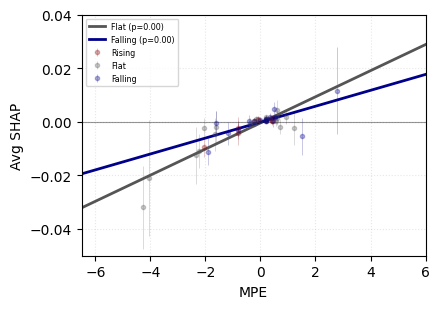

FOLD2 Interaction


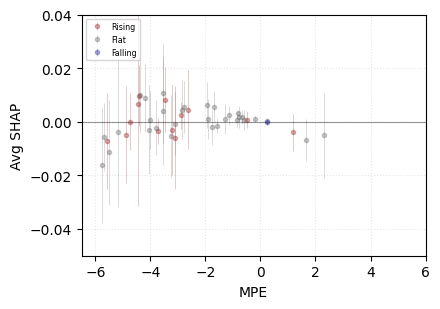

FOLD3 Interaction


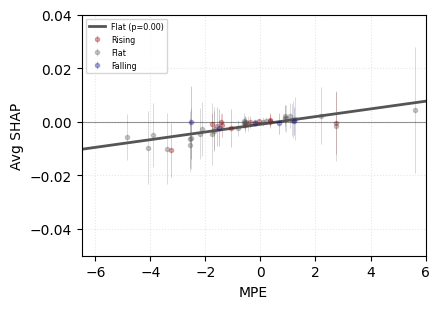

FOLD4 Interaction


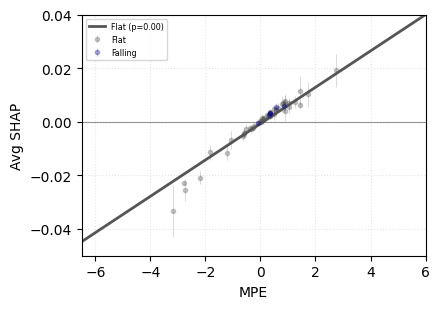

In [13]:
def run_interaction_analysis(target_feat="mp_exp", interact_feat="ffr"):
    colors = {"Rising": "#8b0000", "Flat": "#555555", "Falling": "#00008b"}

    for fold in FOLDS:
        run_dirs = [os.path.join(SAVE_DIR, d) for d in os.listdir(SAVE_DIR) 
                    if d.startswith(fold) and os.path.isdir(os.path.join(SAVE_DIR, d))]
        
        if not run_dirs: continue

        all_X, all_shap = [], []
        features = None

        for fold_dir in run_dirs:
            if features is None: features = load_meta(fold_dir)
            
            x_raw = np.load(os.path.join(fold_dir, "X_explain.npy"))
            s_raw = np.load(os.path.join(fold_dir, "shap_values.npy"))
            
            # We take the first 3 dims. This kills any trailing (..., 1) dimensions 
            # that squeeze might miss if the array is an object type.
            x_3d = x_raw.reshape(x_raw.shape[0], x_raw.shape[1], x_raw.shape[2])
            s_3d = s_raw.reshape(s_raw.shape[0], s_raw.shape[1], s_raw.shape[2])
            
            all_X.append(x_3d)
            all_shap.append(s_3d)

        # Recalculate minimums from the standardized 3D lists
        min_samples = min(x.shape[0] for x in all_X)
        min_lookback = min(x.shape[1] for x in all_X)
        min_feats = min(x.shape[2] for x in all_X)

        # Final Alignment and Stack
        X_aligned = np.stack([x[:min_samples, -min_lookback:, :min_feats] for x in all_X], axis=0)
        shp_aligned = np.stack([s[:min_samples, -min_lookback:, :min_feats] for s in all_shap], axis=0)

        # Average across the 5 runs
        X_mean = np.mean(X_aligned, axis=0)
        shp_mean = np.mean(shp_aligned, axis=0)
        shp_std = np.std(shp_aligned, axis=0)

        t_idx, i_idx = features.index(target_feat), features.index(interact_feat)
        ffr_delta = X_mean[:, -1, i_idx] - X_mean[:, -2, i_idx]

        df_avg = pd.DataFrame({
            "Sentiment": (X_mean[:, -1, t_idx]) ,
            "SHAP_Mean": shp_mean[:, -1, t_idx],
            "SHAP_Std": shp_std[:, -1, t_idx],
            "FFR_Change": ffr_delta
        })

        df_avg["Regime"] = pd.cut(df_avg["FFR_Change"], 
                                   bins=[-np.inf, -0.0001, 0.0001, np.inf], 
                                   labels=["Falling", "Flat", "Rising"], include_lowest=True)

        # Winsorize and Plot
        df_avg["Sentiment"] = winsorize(df_avg["Sentiment"], limits=[0.01, 0.01])
        df_avg["SHAP_Mean"] = winsorize(df_avg["SHAP_Mean"], limits=[0.01, 0.01])

        plt.figure(figsize=(4.5, 3.2))

        for label, color in colors.items():
            subset = df_avg[df_avg["Regime"] == label]
            if subset.empty: continue
            plt.errorbar(subset["Sentiment"], subset["SHAP_Mean"], yerr=subset["SHAP_Std"],
                         fmt='o', color=color, markersize=3, elinewidth=0.5, alpha=0.3, 
                         label=f"{label}", linestyle='None')

        x_range = np.linspace(-10, 10, 100)
        for label in ["Rising", "Flat", "Falling"]:
            subset = df_avg[df_avg["Regime"] == label]
            if len(subset) > 15:
                slope, intercept, r, p, se = stats.linregress(subset["Sentiment"], subset["SHAP_Mean"])
                if p < 0.05:
                    plt.plot(x_range, slope * x_range + intercept, color=colors[label], linewidth=2,
                             label=f"{label} (p={p:.2f})")

        plt.axhline(0, color='black', lw=0.8, alpha=0.4)
        print(f"{fold.upper()} Interaction")
        plt.xlabel("MPE")
        plt.ylabel("Avg SHAP")
        plt.ylim([-0.05,0.04])
        plt.xlim([-6.5,6])
        plt.legend(fontsize='xx-small', loc='upper left'); plt.grid(True, ls=':', alpha=0.3)
        plt.tight_layout(); plt.savefig(f"figures/shap_interaction_{fold}.pdf"); plt.show()

run_interaction_analysis(target_feat="mp_exp", interact_feat="ffr")

### **11) Regime-Dependent Interaction Analysis MPE and FFR (Aggregated)** <a id="11-interactions--agg"></a>

Global Interaction Analysis (Averaged Runs per Observation)


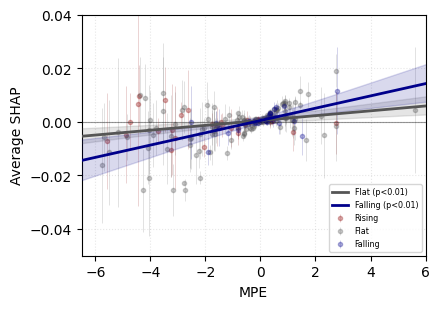

In [14]:
def plot_rescaled_global_interaction(target_feat="mp_exp", interact_feat="ffr"):
    # Small epsilon for "Flat" regime since we are now calculating deltas
    FLAT_THRESHOLD = 0.0001 
    colors = {"Rising": "#8b0000", "Flat": "#555555", "Falling": "#00008b"}
    
    all_fold_averages = []

    for fold in FOLDS:
        run_dirs = [os.path.join(SAVE_DIR, d) for d in os.listdir(SAVE_DIR) 
                    if d.startswith(fold) and os.path.isdir(os.path.join(SAVE_DIR, d))]
        
        if not run_dirs: continue
        
        fold_X_list = []
        fold_shp_list = []
        features = None
        min_lookback = 999

        # Load and find minimum lookback for alignment within the fold
        for fold_dir in run_dirs:
            if features is None:
                features = load_meta(fold_dir)
            
            X_ex = np.squeeze(np.load(os.path.join(fold_dir, "X_explain.npy")))
            shp  = np.squeeze(np.load(os.path.join(fold_dir, "shap_values.npy")))
            
            min_lookback = min(min_lookback, X_ex.shape[1])
            fold_X_list.append(X_ex)
            fold_shp_list.append(shp)

        # Align and Stack along a NEW axis (Runs, Samples, Lags, Features)
        # This allows us to calculate the mean/std PER observation across the 5 runs
        X_aligned = np.stack([x[:, -min_lookback:, :] for x in fold_X_list], axis=0)
        shp_aligned = np.stack([s[:, -min_lookback:, :] for s in fold_shp_list], axis=0)

        # Calculate Mean and Std across runs (axis 0)
        X_mean = np.mean(X_aligned, axis=0)
        shp_mean = np.mean(shp_aligned, axis=0)
        shp_std = np.std(shp_aligned, axis=0)

        t_idx = features.index(target_feat)
        i_idx = features.index(interact_feat)

        # Correct Delta logic for FFR
        ffr_delta = X_mean[:, -1, i_idx] - X_mean[:, -2, i_idx]
        
        # Reconstruct unscaled sentiment
        original_sentiment = (X_mean[:, -1, t_idx] )

        df_fold = pd.DataFrame({
            "Sentiment": original_sentiment,
            "SHAP_Mean": shp_mean[:, -1, t_idx],
            "SHAP_Std": shp_std[:, -1, t_idx],
            "FFR_Change": ffr_delta
        })
        all_fold_averages.append(df_fold)

    # Concatenate all averaged folds
    df_global = pd.concat(all_fold_averages, ignore_index=True)

    # Define Regimes based on average FFR delta
    df_global["Regime"] = pd.cut(df_global["FFR_Change"], 
                                 bins=[-np.inf, -FLAT_THRESHOLD, FLAT_THRESHOLD, np.inf], 
                                 labels=["Falling", "Flat", "Rising"], 
                                 include_lowest=True)

    # Winsorize for visual clarity
    df_global["SHAP_Mean"] = winsorize(df_global["SHAP_Mean"], limits=[0.01, 0.01])

    plt.figure(figsize=(4.5, 3.2))
    
    # Plot averaged points with Error Bars
    for label, color in colors.items():
        subset = df_global[df_global["Regime"] == label]
        if subset.empty: continue
        
        plt.errorbar(
            subset["Sentiment"], subset["SHAP_Mean"], yerr=subset["SHAP_Std"],
            fmt='o', color=color, markersize=3, elinewidth=0.4, capsize=0, 
            alpha=0.3, label=f"{label}", linestyle='None', zorder=1
        )

    # Global Regression on the Averaged Data
    x_range = np.linspace(df_global["Sentiment"].min(), df_global["Sentiment"].max(), 100) 

    for label in ["Rising", "Flat", "Falling"]:
        subset = df_global[df_global["Regime"] == label]
        if len(subset) < 20: continue
        
        color = colors[label]
        slope, intercept, r_val, p_val, std_err = stats.linregress(subset["Sentiment"], subset["SHAP_Mean"])
        
        if p_val < 0.01:
            y_range = slope * x_range + intercept
            
            # Confidence Interval Calculation
            n = len(subset)
            x_m = subset["Sentiment"].mean()
            sse = np.sum((subset["SHAP_Mean"] - (slope * subset["Sentiment"] + intercept))**2)
            std_err_resid = np.sqrt(sse / (n - 2))
            ssx = np.sum((subset["Sentiment"] - x_m)**2)
            se_band = std_err_resid * np.sqrt(1/n + (x_range - x_m)**2 / ssx)
            t_val = stats.t.ppf(0.975, n - 2)
            
            plt.fill_between(x_range, y_range - t_val * se_band, y_range + t_val * se_band, 
                             color=color, alpha=0.15, zorder=5)
            plt.plot(x_range, y_range, color=color, linewidth=2, 
                     label=f"{label} (p<0.01)", zorder=10)

    plt.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.4)
    plt.xlim(-0.6, 0.6) # Adjust limits based on your specific distribution
    
    print("Global Interaction Analysis (Averaged Runs per Observation)")
    plt.xlabel("MPE")
    plt.ylabel("Average SHAP")
    plt.ylim([-0.05,0.04])
    plt.xlim([-6.5,6])
    plt.legend(frameon=True, loc='best', fontsize='xx-small', ncol=1)
    plt.grid(True, linestyle=':', alpha=0.3)
    plt.tight_layout()
    plt.savefig("figures/shap_interaction_global.pdf")

plot_rescaled_global_interaction()
plt.show()